## 1. Project organization


tesis_nanopore_meth/
│── data_raw/
│── data_bam/
│── data_methylation/
│── genomes/
│── notebooks/
│── scripts/


data_raw/ → FASTQ originales

data_bam/ → archivos BAM alineados

data_methylation/ → resultados de modkit

genomes/ → FASTA de referencia (GRCh38)

notebooks/ → análisis exploratorios y finales

## 2. Lectura del TSV en Python

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("../data_methylation/methylation.tsv", sep="\t", header=None)

In [ ]:
df.columns = [
    "chrom",        # 1
    "start",        # 2
    "end",          # 3
    "mod",          # 4  -> 'm' = 5mC, 'h' = 5hmC
    "score",        # 5  -> usualmente 0/1 o valor dummy
    "strand",       # 6  -> '+' o '-'
    "thickStart",   # 7
    "thickEnd",     # 8
    "itemRgb",      # 9  -> '255,0,0'
    "valid_cov",    # 10 -> reads con llamada válida
    "percent_mod",  # 11 -> % modificado (ej. 100.00)
    "num_mod",      # 12 -> # lecturas modificadas
    "num_canon",    # 13 -> # lecturas canónicas
    "num_other_mod",# 14 -> otras mods
    "num_del",      # 15 -> lecturas con deleción
    "num_lowconf",  # 16 -> llamadas de baja confianza
    "num_mismatch", # 17 -> lecturas con mismatch
    "num_nocall"    # 18 -> lecturas sin llamada de mod
]

In [ ]:
df.head()

,chrom,start,end,mod,score,strand,thickStart,thickEnd,itemRgb,valid_cov,percent_mod,num_mod,num_canon,num_other_mod,num_del,num_lowconf,num_mismatch,num_nocall
0,chr1,102871,102872,h,1,-,102871,102872,"255,0,0",1,0.0,0,1,0,0,0,0,0
1,chr1,102871,102872,m,1,-,102871,102872,"255,0,0",1,0.0,0,1,0,0,0,0,0
2,chr1,102873,102874,h,1,-,102873,102874,"255,0,0",1,0.0,0,1,0,0,0,0,0
3,chr1,102873,102874,m,1,-,102873,102874,"255,0,0",1,0.0,0,1,0,0,0,0,0
4,chr1,102877,102878,h,1,-,102877,102878,"255,0,0",1,0.0,0,1,0,0,0,0,0


In [ ]:
df["percent_mod"] = df["percent_mod"].astype(float)
df["fraction"] = df["percent_mod"] / 100.0

## Coverage bias in methylation fraction

The `fraction` value represents the proportion of methylated reads at a given site.

In this dataset, most CpG sites have **very low coverage (valid_cov = 1)**.  
This leads to extreme values:

- `fraction = 0` → the single read is not methylated  
- `fraction = 1` → the single read is methylated  

As a result, the distribution is dominated by 0s and 1s, with very few intermediate values.

This does **not reflect true biological methylation**, but rather **low sequencing depth**.

### Implication

A value of `fraction = 0` at low coverage does **not reliably indicate absence of methylation**.

### Approach

To improve reliability, filtering by coverage is required:

- `valid_cov ≥ 2` for exploratory analysis  
- `valid_cov ≥ 5` for more robust estimates  

This step is essential when working with Nanopore methylation data, especially from targeted panels.

In [ ]:
df["fraction"].value_counts()

fraction
0.0    527912
1.0     11401
0.5        17
Name: count, dtype: int64

In [ ]:
df["fraction"].describe()
df[df["fraction"] > 0].head()

,chrom,start,end,mod,score,strand,thickStart,thickEnd,itemRgb,valid_cov,percent_mod,num_mod,num_canon,num_other_mod,num_del,num_lowconf,num_mismatch,num_nocall,fraction
151,chr1,103169,103170,m,1,-,103169,103170,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
207,chr1,636983,636984,m,1,+,636983,636984,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
232,chr1,637037,637038,h,1,+,637037,637038,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
251,chr1,637088,637089,m,1,+,637088,637089,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
337,chr1,637255,637256,m,1,+,637255,637256,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0


In [ ]:
df[df["fraction"] > 0.2].head()


,chrom,start,end,mod,score,strand,thickStart,thickEnd,itemRgb,valid_cov,percent_mod,num_mod,num_canon,num_other_mod,num_del,num_lowconf,num_mismatch,num_nocall,fraction
151,chr1,103169,103170,m,1,-,103169,103170,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
207,chr1,636983,636984,m,1,+,636983,636984,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
232,chr1,637037,637038,h,1,+,637037,637038,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
251,chr1,637088,637089,m,1,+,637088,637089,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
337,chr1,637255,637256,m,1,+,637255,637256,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0


In [ ]:
df_m = df[df["mod"] == "m"]  # 5mC
df_h = df[df["mod"] == "h"]  # 5hmC


In [ ]:
df["mod"].value_counts()


mod
h    269665
m    269665
Name: count, dtype: int64

## Coverage filtering strategy
Methylation analysis was initially explored using higher coverage thresholds (e.g., valid_cov ≥ 2 or ≥ 5).  
However, applying these filters drastically reduced the number of available CpG sites, due to the limited sequencing depth of the dataset.

As a result, the analysis was performed using **valid_cov ≥ 1**, in order to retain sufficient data for exploratory analysis.

### Implications

This choice introduces important limitations:

- Many sites are supported by a single read
- Methylation fractions are often binary (0 or 1)
- Estimates are less reliable and more prone to noise

### Interpretation

Results should therefore be considered **exploratory**, and not representative of precise methylation levels.

Despite these limitations, this approach allows identification of general patterns and candidate regions for further investigation.

In [ ]:
cutoff = 1
df_filt = df[df["valid_cov"] >= cutoff].copy()


In [ ]:

df_m = df_filt[df_filt["mod"] == "m"].copy()   # 5mC
df_h = df_filt[df_filt["mod"] == "h"].copy()   # 5hmC (lo dejamos para después)


In [ ]:

display(df_m["fraction"].describe())
display(df_m[df_m["fraction"] > 0.2].head())


count    269665.000000
mean          0.039302
std           0.194278
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: fraction, dtype: float64

,chrom,start,end,mod,score,strand,thickStart,thickEnd,itemRgb,valid_cov,percent_mod,num_mod,num_canon,num_other_mod,num_del,num_lowconf,num_mismatch,num_nocall,fraction
151,chr1,103169,103170,m,1,-,103169,103170,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
207,chr1,636983,636984,m,1,+,636983,636984,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
251,chr1,637088,637089,m,1,+,637088,637089,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
337,chr1,637255,637256,m,1,+,637255,637256,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0
403,chr1,2090366,2090367,m,1,+,2090366,2090367,"255,0,0",1,100.0,1,0,0,0,0,0,0,1.0


In [ ]:
# 6) Exportar BED para 5mC (incluyo valid_cov, útil para QA y agregación)
df_bed = df_m[["chrom", "start", "end", "fraction", "valid_cov"]].copy()

out_bed = f"../data_methylation/methylation_5mC_cov{cutoff}.bed"
df_bed.to_csv(out_bed, sep="\t", header=False, index=False)

print("BED guardado en:", out_bed)
print("Filas exportadas:", len(df_bed))

BED guardado en: ../data_methylation/methylation_5mC_cov1.bed
Filas exportadas: 269665


In [ ]:
df_bed.shape

(269665, 5)

## Gene body methylation summary

To explore methylation patterns at the gene level, CpG sites were intersected with gene bodies and aggregated by gene.

Because applying stricter coverage thresholds greatly reduced the number of available sites, this exploratory analysis was performed using sites with `valid_cov >= 1`. Results should therefore be interpreted cautiously.

In [ ]:
import pandas as pd

x1 = pd.read_csv("../data_methylation/5mC_cov1_x_genes.tsv", sep="\t", header=None)

x1.columns = [
    "chrom","start","end","fraction","valid_cov",
    "g_chrom","g_start","g_end","gene_id","gene_name","gene_strand"
]
x1.head()

,chrom,start,end,fraction,valid_cov,g_chrom,g_start,g_end,gene_id,gene_name,gene_strand
0,chr4,190179396,190179397,0.0,2,chr4,190173773,190185942,ENSG00000260596.5,DUX4,+
1,chr4,190179408,190179409,0.0,2,chr4,190173773,190185942,ENSG00000260596.5,DUX4,+
2,chr4,190179410,190179411,0.0,2,chr4,190173773,190185942,ENSG00000260596.5,DUX4,+
3,chr4,190179411,190179412,0.0,2,chr4,190173773,190185942,ENSG00000260596.5,DUX4,+
4,chr4,190179420,190179421,0.0,2,chr4,190173773,190185942,ENSG00000260596.5,DUX4,+


In [ ]:
# Tabla de resumen por gen

In [ ]:
gene_summary_cov1 = (
    x1.groupby(["gene_id","gene_name"])
      .agg(
        mean_methylation=("fraction","mean"),
        median_methylation=("fraction","median"),
        n_sites=("fraction","size"),
        mean_cov=("valid_cov","mean"),
      )
      .reset_index()
      .sort_values(["n_sites","mean_methylation"], ascending=[False, False])
)
gene_summary_cov1.head(10)

,gene_id,gene_name,mean_methylation,median_methylation,n_sites,mean_cov
853,ENSG00000159216.19,RUNX1,0.032872,0.0,2312,1.0
43,ENSG00000044115.21,CTNNA1,0.053652,0.0,2218,1.0
944,ENSG00000166225.9,FRS2,0.046538,0.0,1762,1.0
692,ENSG00000147050.18,KDM6A,0.056005,0.0,1732,1.0
347,ENSG00000115170.16,ACVR1,0.050598,0.0,1087,1.0
1717,ENSG00000253404.1,CTNNA1-AS1,0.055838,0.0,985,1.0
220,ENSG00000102900.13,NUP93,0.035569,0.0,984,1.0
430,ENSG00000124151.19,NCOA3,0.048619,0.0,905,1.0
1244,ENSG00000196092.14,PAX5,0.067164,0.0,804,1.0
1199,ENSG00000185920.19,PTCH1,0.041772,0.0,790,1.0


In [ ]:
gene_summary_cov1.shape



(2170, 6)

## Promoter-level methylation analysis

To focus on regulatory regions, CpG sites were intersected with promoter coordinates and summarized at the gene level.

Promoter methylation is particularly relevant because it may be associated with transcriptional regulation.  
As in the gene body analysis, sites with `valid_cov >= 1` were retained due to the limited coverage of the dataset, so results should be interpreted as exploratory.

In [ ]:
xp = pd.read_csv("../data_methylation/5mC_cov1_x_promoters.tsv", sep="\t", header=None)

xp.columns = [
    "chrom","start","end","fraction","valid_cov",
    "p_chrom","p_start","p_end","gene_id","gene_name","strand"
]

promoter_summary = (
    xp.groupby(["gene_id","gene_name"])
      .agg(
        mean_methylation=("fraction","mean"),
        median_methylation=("fraction","median"),
        n_sites=("fraction","size"),
        mean_cov=("valid_cov","mean")
      )
      .reset_index()
      .sort_values(["n_sites","mean_methylation"], ascending=[False, False])
)

promoter_summary.head(10)


,gene_id,gene_name,mean_methylation,median_methylation,n_sites,mean_cov
118,ENSG00000210077.1,MT-TV,0.016632,0.0,481,1.122661
119,ENSG00000210082.2,MT-RNR2,0.016632,0.0,481,1.122661
116,ENSG00000209082.1,MT-TL1,0.010782,0.0,371,1.000000
321,ENSG00000278418.1,MIR6512,0.005510,0.0,363,1.000000
94,ENSG00000198888.2,MT-ND1,0.011396,0.0,351,1.000000
117,ENSG00000210049.1,MT-TF,0.024465,0.0,327,1.180428
138,ENSG00000211459.2,MT-RNR1,0.024465,0.0,327,1.180428
18,ENSG00000111252.11,SH2B3,0.007168,0.0,279,1.000000
320,ENSG00000278413.1,ENSG00000278413,0.024590,0.0,244,1.000000
89,ENSG00000198763.3,MT-ND2,0.000000,0.0,234,1.000000


In [ ]:
promoter_summary.shape


(377, 6)

## Excluding mitochondrial genes

Mitochondrial genes were excluded from downstream prioritization because they were highly represented and could dominate the ranking, potentially obscuring more informative nuclear genes.

In [ ]:
# Remove mitochondrial genes
promoter_summary["is_mito"] = promoter_summary["gene_name"].astype(str).str.startswith("MT-")

promoter_summary_nuc = promoter_summary[~promoter_summary["is_mito"]].copy()

print(
    "Total:", len(promoter_summary),
    "Nuclear:", len(promoter_summary_nuc),
    "Mito:", promoter_summary["is_mito"].sum()
)

promoter_summary_nuc.to_csv("results/promoter_summary_nuclear.tsv", sep="\t", index=False)

Total: 377 Nuclear: 341 Mito: 36


## Prioritizing promoter-level candidate genes

Because average coverage was low, the number of CpG sites per promoter (`n_sites`) was used as the main robustness criterion.

Two simple prioritization levels were defined:

- `n_sites ≥ 20`: initial candidate genes
- `n_sites ≥ 50`: more robust promoter-level candidates

This approach helps reduce noise from sparsely covered promoters while retaining enough signal for exploratory interpretation.

In [ ]:
min_sites = 20
cand = promoter_summary_nuc[promoter_summary_nuc["n_sites"] >= min_sites].copy()

# rank por metilación promedio
cand = cand.sort_values(["mean_methylation","n_sites"], ascending=[False, False])

print("Candidatos:", cand.shape)
display(cand.head(20))

Candidatos: (310, 7)


,gene_id,gene_name,mean_methylation,median_methylation,n_sites,mean_cov,is_mito
254,ENSG00000286148.1,ENSG00000286148,0.470588,0.0,51,1.0,False
78,ENSG00000275664.1,ENSG00000275664,0.405405,0.0,111,1.0,False
79,ENSG00000275950.1,MIR6724-1,0.405405,0.0,111,1.0,False
86,ENSG00000286032.1,ENSG00000286032,0.398148,0.0,108,1.0,False
87,ENSG00000286091.1,ENSG00000286091,0.398148,0.0,108,1.0,False
103,ENSG00000275708.1,MIR3648-1,0.375000,0.0,96,1.0,False
129,ENSG00000201321.1,RNA5S9,0.325581,0.0,86,1.0,False
75,ENSG00000199910.1,RNA5S10,0.315789,0.0,114,1.0,False
136,ENSG00000160360.13,GPSM1,0.301205,0.0,83,1.0,False
137,ENSG00000262075.3,DKFZP434A062,0.301205,0.0,83,1.0,False


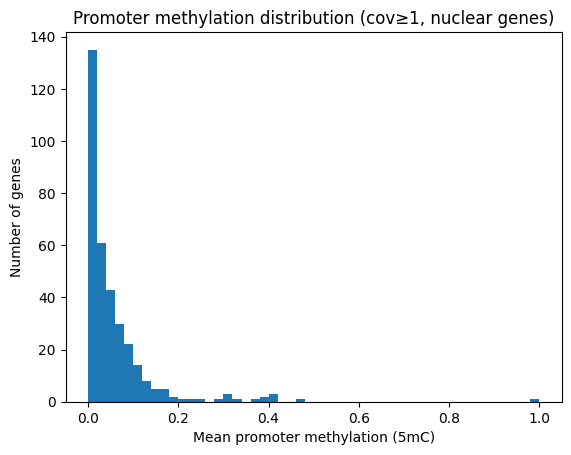

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(promoter_summary_nuc["mean_methylation"].fillna(0), bins=50)
plt.xlabel("Mean promoter methylation (5mC)")
plt.ylabel("Number of genes")
plt.title("Promoter methylation distribution (cov≥1, nuclear genes)")
plt.show()


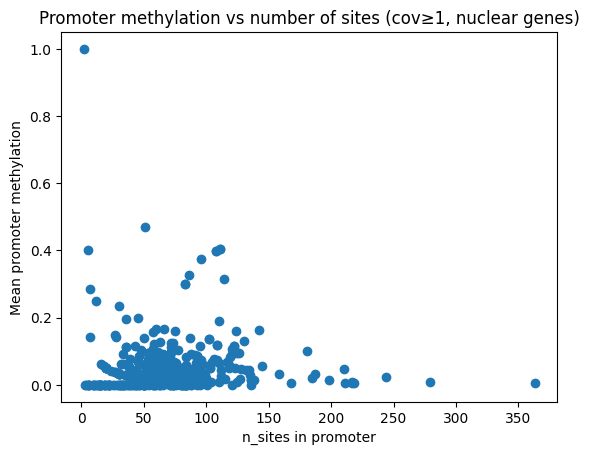

In [ ]:
plt.figure()
plt.scatter(promoter_summary_nuc["n_sites"], promoter_summary_nuc["mean_methylation"])
plt.xlabel("n_sites in promoter")
plt.ylabel("Mean promoter methylation")
plt.title("Promoter methylation vs number of sites (cov≥1, nuclear genes)")
plt.show()


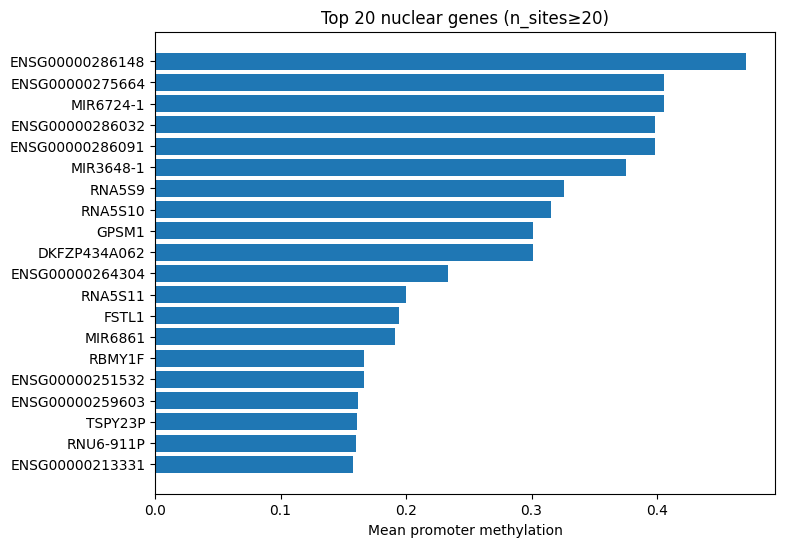

In [ ]:
top20 = cand.head(20).sort_values("mean_methylation")  # para que el barplot quede lindo

plt.figure(figsize=(8,6))
plt.barh(top20["gene_name"], top20["mean_methylation"])
plt.xlabel("Mean promoter methylation")
plt.title(f"Top 20 nuclear genes (n_sites≥{min_sites})")
plt.show()


In [ ]:
cand['mean_cov'].value_counts()

mean_cov
1.000000    309
1.025253      1
Name: count, dtype: int64

In [ ]:
cand.n_sites.describe()

count    310.000000
mean      77.003226
std       43.482429
min       20.000000
25%       49.000000
50%       71.000000
75%       94.000000
max      363.000000
Name: n_sites, dtype: float64

In [ ]:
strong_candidates = promoter_summary_nuc[promoter_summary_nuc["n_sites"] >= 50]\
    .sort_values("mean_methylation", ascending=False)

strong_candidates.head(20)


,gene_id,gene_name,mean_methylation,median_methylation,n_sites,mean_cov,is_mito
254,ENSG00000286148.1,ENSG00000286148,0.470588,0.0,51,1.0,False
78,ENSG00000275664.1,ENSG00000275664,0.405405,0.0,111,1.0,False
79,ENSG00000275950.1,MIR6724-1,0.405405,0.0,111,1.0,False
87,ENSG00000286091.1,ENSG00000286091,0.398148,0.0,108,1.0,False
86,ENSG00000286032.1,ENSG00000286032,0.398148,0.0,108,1.0,False
103,ENSG00000275708.1,MIR3648-1,0.375000,0.0,96,1.0,False
129,ENSG00000201321.1,RNA5S9,0.325581,0.0,86,1.0,False
75,ENSG00000199910.1,RNA5S10,0.315789,0.0,114,1.0,False
136,ENSG00000160360.13,GPSM1,0.301205,0.0,83,1.0,False
137,ENSG00000262075.3,DKFZP434A062,0.301205,0.0,83,1.0,False


In [ ]:
strong_candidates.shape


(230, 7)

In [ ]:
strong_candidates["mean_methylation"].describe()


count    230.000000
mean       0.060502
std        0.079312
min        0.000000
25%        0.012415
50%        0.038462
75%        0.077462
max        0.470588
Name: mean_methylation, dtype: float64

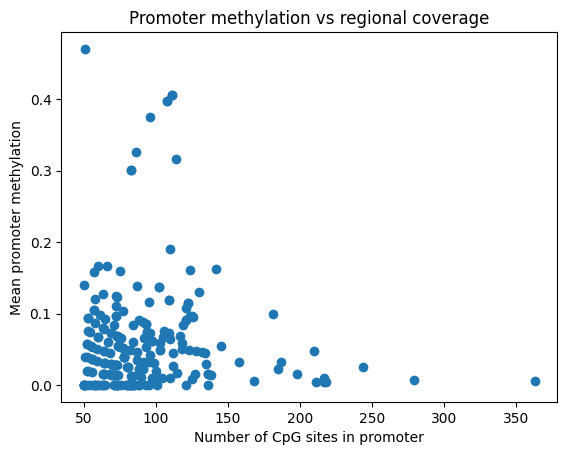

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(strong_candidates["n_sites"],
            strong_candidates["mean_methylation"])
plt.xlabel("Number of CpG sites in promoter")
plt.ylabel("Mean promoter methylation")
plt.title("Promoter methylation vs regional coverage")
plt.show()


## Evaluation of known lung cancer genes

A set of well-characterized lung cancer genes (e.g., TP53, EGFR, KRAS) was examined.

No strong methylation signal was observed in these genes under the current filtering strategy.

This may reflect:
- limited sequencing depth
- lack of sufficient CpG coverage in these regions
- or absence of strong promoter methylation in this dataset

This result highlights the limitations of the data and the need for higher coverage or multi-omics integration.

In [ ]:
lung_genes = ["TP53","EGFR","KRAS","STK11","KEAP1","ALK","ROS1","MET","BRAF","PIK3CA","PTEN","RB1","CDKN2A"]
promoter_summary_nuc[promoter_summary_nuc["gene_name"].isin(lung_genes)]\
    .sort_values(["n_sites","mean_methylation"], ascending=[False, False])


,gene_id,gene_name,mean_methylation,median_methylation,n_sites,mean_cov,is_mito
